In [1]:
#### Librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)


from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

In [2]:
### Funciones utiles 

###Transforma objeto a numerico,  a los espacios vacios los pone como nan
def coerce_totalcharges(X):
    X = X.copy()
    X["TotalCharges"] = pd.to_numeric(X["TotalCharges"].astype(str).str.strip(), errors="coerce")
    return X

### Calculo del treshold optimo en base a f1
def best_threshold_f1(y_true, y_proba):
    """
    Devuelve (best_thr, best_f1, prec_at_thr, rec_at_thr, prec_vec, rec_vec, thr_vec).
    Nota: precision_recall_curve devuelve thr con len = len(prec)-1.
    """
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1 = 2*(prec[:-1]*rec[:-1])/(prec[:-1]+rec[:-1]+1e-12)
    best_idx = int(np.argmax(f1))
    best_thr = float(thr[best_idx])
    return best_thr, float(f1[best_idx]), float(prec[:-1][best_idx]), float(rec[:-1][best_idx]), prec, rec, thr


#### Calcular el threshold sin leakage (OOF en train)
def threshold_f1_cv(estimator, X_train, y_train, cv):
    y_proba_oof = cross_val_predict(
        estimator, X_train, y_train,
        cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    best_thr, *_ = best_threshold_f1(y_train, y_proba_oof)
    return best_thr


#### Metricas y la matriz de confusion a partir de un threshold dado
def summarize_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "thr": float(thr),
        "precision_1": precision_score(y_true, y_pred, pos_label=1),
        "recall_1": recall_score(y_true, y_pred, pos_label=1),
        "f1_1": f1_score(y_true, y_pred, pos_label=1),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)
    }


#### Resumen final del modelo y sus distintas metricas
def summary_metrics(y_true, y_proba, model_name, thr_default=0.5, thr_f1=None, as_df=True):
    """
    Resumen de métricas para:
    - ROC AUC, PR AUC
    - thr=0.5
    - thr=F1 (si no se pasa, lo calcula sobre (y_true,y_proba))

    Devuelve DataFrame (1 fila) por default. Si as_df=False devuelve dict.
    """
    roc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)

    if thr_f1 is None:
        thr_f1, *_ = best_threshold_f1(y_true, y_proba)   # <-- FIX

    s_05 = summarize_threshold(y_true, y_proba, thr_default)
    s_f1 = summarize_threshold(y_true, y_proba, thr_f1)

    row = {
        "model": model_name,
        "roc_auc": roc,
        "pr_auc": pr,

        "thr_05": s_05["thr"],
        "P1_05": s_05["precision_1"],
        "R1_05": s_05["recall_1"],
        "F1_05": s_05["f1_1"],
        "FN_05": s_05["FN"],
        "FP_05": s_05["FP"],

        "thr_f1": s_f1["thr"],
        "P1_f1": s_f1["precision_1"],
        "R1_f1": s_f1["recall_1"],
        "F1_f1": s_f1["f1_1"],
        "FN_f1": s_f1["FN"],
        "FP_f1": s_f1["FP"],
    }

    return pd.DataFrame([row]) if as_df else row

In [3]:
# cargo los datasets 
data_test = pd.read_csv('churn_test.csv')
data_train = pd.read_csv('churn_train.csv')

In [4]:
### armo las matrices de variables y el objetivo
x = data_train.drop(columns='Churn')
y = data_train['Churn']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 110, stratify=y)

In [6]:
# definimos las variables categoricas y numericas de nuestro dataset
var_num = ['MonthlyCharges', 'TotalCharges', 'tenure']
var_cat = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


numeric_pipe = Pipeline([
    ("to_num", FunctionTransformer(coerce_totalcharges, feature_names_out="one-to-one")),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  # útil para Logit; innecesario para RF/XGB
])

categorical_pipe = Pipeline([
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, var_num),
        ("cat", categorical_pipe, var_cat)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")


In [7]:
dummy = Pipeline([
    ("prep", preprocessor),
    ("dum", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(x_train, y_train)
y_proba_dummy = dummy.predict_proba(x_test)[:, 1]

print("Dummy ROC AUC (test):", roc_auc_score(y_test, y_proba_dummy))
print("Dummy PR AUC (test):", average_precision_score(y_test, y_proba_dummy))

Dummy ROC AUC (test): 0.5
Dummy PR AUC (test): 0.26552335895919577


In [8]:
#### aplicamos el modelo 

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=5000))
])


param_grid = [
    {   # liblinear soporta l1 y l2
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear"],
        "clf__class_weight": [None, "balanced"],
    },
    {   # lbfgs soporta solo l2
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
        "clf__class_weight": [None, "balanced"],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(x_train, y_train)
best_model = grid.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [9]:
### Evaluacion del modelo 
# Threshold default (0.5)
y_proba_test = best_model.predict_proba(x_test)[:, 1]
thr_05 = 0.5
y_pred_05 = (y_proba_test >= thr_05).astype(int)

print("ROC AUC (test):", roc_auc_score(y_test, y_proba_test))
print("\nMatriz de confusión (thr=0.5):\n", confusion_matrix(y_test, y_pred_05))
print("\nReporte (thr=0.5):\n", classification_report(y_test, y_pred_05))


## modificamos el treshold en base a una metricca mas acorde al problema 

# 1) Elegimos threshold con TRAIN (OOF) => sin leakage
cv_thr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_thr_cv = threshold_f1_cv(best_model, x_train, y_train, cv_thr)
print("Best threshold (F1) elegido con TRAIN-CV:", best_thr_cv)

#Evaluamos en TEST usando ese threshold
y_proba_test = best_model.predict_proba(x_test)[:, 1]
y_pred_f1 = (y_proba_test >= best_thr_cv).astype(int)

print("\nMatriz confusión (thr TRAIN-CV):\n", confusion_matrix(y_test, y_pred_f1))
print("\nReporte (thr TRAIN-CV):\n", classification_report(y_test, y_pred_f1))

ROC AUC (test): 0.8299342966477662

Matriz de confusión (thr=0.5):
 [[1096  146]
 [ 209  240]]

Reporte (thr=0.5):
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1242
           1       0.62      0.53      0.57       449

    accuracy                           0.79      1691
   macro avg       0.73      0.71      0.72      1691
weighted avg       0.78      0.79      0.78      1691

Best threshold (F1) elegido con TRAIN-CV: 0.3207103905483986

Matriz confusión (thr TRAIN-CV):
 [[942 300]
 [117 332]]

Reporte (thr TRAIN-CV):
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1242
           1       0.53      0.74      0.61       449

    accuracy                           0.75      1691
   macro avg       0.71      0.75      0.72      1691
weighted avg       0.79      0.75      0.76      1691



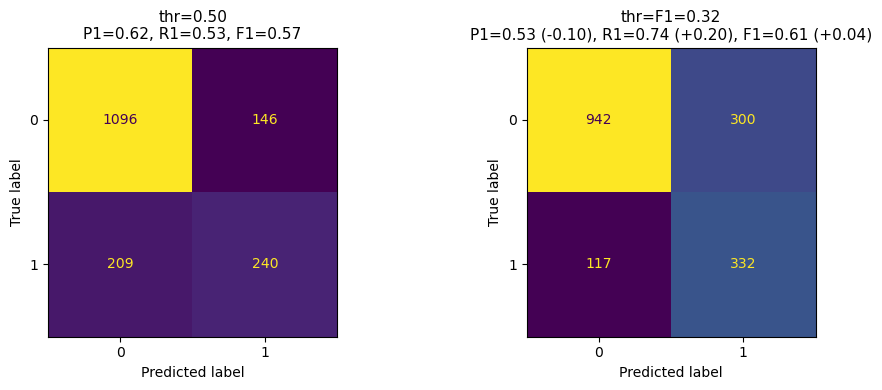

In [10]:
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_cv_logit = confusion_matrix(y_test, y_pred_f1)

# Métricas de la clase positiva (churn=1)
p05 = precision_score(y_test, y_pred_05, pos_label=1)
r05 = recall_score(y_test, y_pred_05, pos_label=1)
f05 = f1_score(y_test, y_pred_05, pos_label=1)

pf1 = precision_score(y_test, y_pred_f1, pos_label=1)
rf1 = recall_score(y_test, y_pred_f1, pos_label=1)
ff1 = f1_score(y_test, y_pred_f1, pos_label=1)

# Deltas (cambio vs thr=0.5)
dp, dr, df = pf1 - p05, rf1 - r05, ff1 - f05

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(top=0.85)

ConfusionMatrixDisplay(cm_05).plot(ax=axes[0], colorbar=False)
axes[0].set_title(
    f"thr=0.50\n"
    f"P1={p05:.2f}, R1={r05:.2f}, F1={f05:.2f}",fontsize=11
)

ConfusionMatrixDisplay(cm_cv_logit).plot(ax=axes[1], colorbar=False)
axes[1].set_title(
    f"thr=F1={best_thr_cv:.2f}\n"
    f"P1={pf1:.2f} ({dp:+.2f}), R1={rf1:.2f} ({dr:+.2f}), F1={ff1:.2f} ({df:+.2f})",fontsize=11
)

plt.tight_layout()
plt.show()

In [11]:
# 1) nombres de features después del preprocesado (ya entrenado)
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# 2) coeficientes del modelo
coef = best_model.named_steps["clf"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef),
    "odds_ratio": np.exp(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(10)

,feature,coef,abs_coef,odds_ratio
10,InternetService_Fiber optic,1.925646,1.925646,6.859581
25,Contract_Two year,-1.431001,1.431001,0.239070
2,tenure,-1.349610,1.349610,0.259341
0,MonthlyCharges,-1.311354,1.311354,0.269455
8,MultipleLines_No phone service,-0.900567,0.900567,0.406339
7,PhoneService_Yes,-0.824929,0.824929,0.438266
24,Contract_One year,-0.776522,0.776522,0.460003
21,StreamingTV_Yes,0.684686,0.684686,1.983149
1,TotalCharges,0.648655,0.648655,1.912967
23,StreamingMovies_Yes,0.598973,0.598973,1.820249


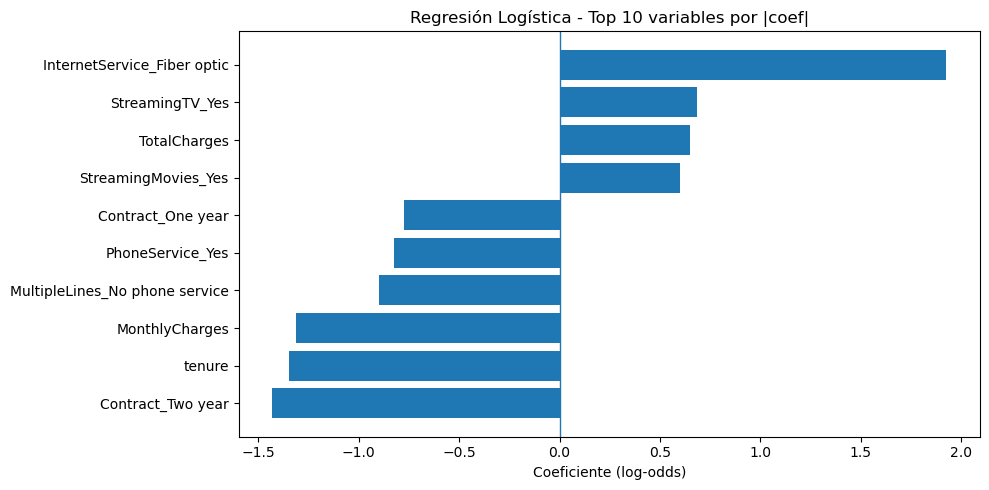

In [12]:
top_n = 10

plot_df = (
    coef_df.sort_values("abs_coef", ascending=False)
           .head(top_n)
           .sort_values("coef")
           .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
y_pos = np.arange(len(plot_df))     # <- no pises y
plt.barh(y_pos, plot_df["coef"])
plt.yticks(y_pos, plot_df["feature"])
plt.axvline(0, linewidth=1)
plt.title(f"Regresión Logística - Top {top_n} variables por |coef|")
plt.xlabel("Coeficiente (log-odds)")
plt.tight_layout()
plt.show()

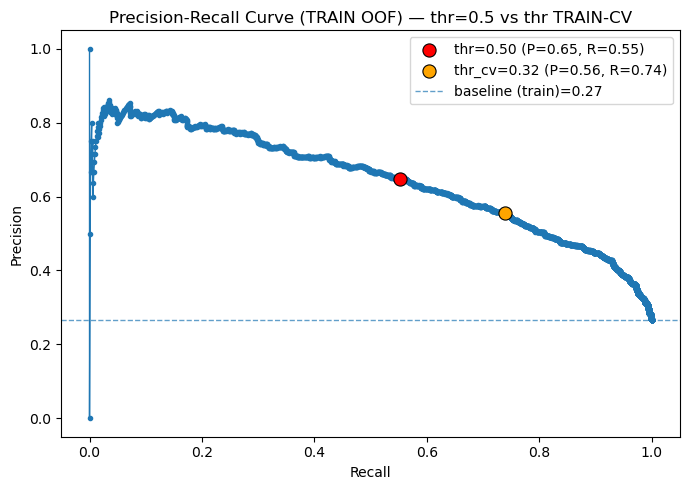

In [13]:

##### PR curve consistente: TRAIN (OOF) + puntos thr=0.5 y thr_cv

y_proba_oof = cross_val_predict(
    best_model, x_train, y_train,
    cv=cv_thr, method="predict_proba", n_jobs=-1
)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, y_proba_oof)

# ubicar thresholds en el vector thr 
idx_05 = np.argmin(np.abs(thr - 0.5))
idx_cv = np.argmin(np.abs(thr - best_thr_cv))

plt.figure(figsize=(7, 5))

# curva 
plt.plot(rec, prec, marker=".", linewidth=1, zorder=1)

# punto thr=0.5 
plt.scatter(rec[:-1][idx_05], prec[:-1][idx_05],
            s=90, color="red", edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr=0.50 (P={prec[:-1][idx_05]:.2f}, R={rec[:-1][idx_05]:.2f})")

# punto thr_cv 
plt.scatter(rec[:-1][idx_cv], prec[:-1][idx_cv],
            s=90, color="orange", edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr_cv={best_thr_cv:.2f} (P={prec[:-1][idx_cv]:.2f}, R={rec[:-1][idx_cv]:.2f})")

# baseline (tasa positiva en train)
baseline = y_train.mean()
plt.axhline(baseline, linestyle="--", linewidth=1, alpha=0.7,
            label=f"baseline (train)={baseline:.2f}")

plt.title("Precision-Recall Curve (TRAIN OOF) — thr=0.5 vs thr TRAIN-CV")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
summary_logit = summary_metrics(
    y_test,
    y_proba_test,
    model_name="Logit",
    thr_f1=best_thr_cv   # <- elegido en TRAIN-CV
)
summary_logit

,model,roc_auc,pr_auc,thr_05,P1_05,R1_05,F1_05,FN_05,FP_05,thr_f1,P1_f1,R1_f1,F1_f1,FN_f1,FP_f1
0,Logit,0.829934,0.618721,0.5,0.621762,0.534521,0.57485,209,146,0.32071,0.525316,0.739421,0.614246,117,300


El modelo logra un buen desempeño de ranking (ROC AUC y PR AUC superiores al baseline), y permite interpretar los principales drivers del churn mediante coeficientes y odds ratios. Con el umbral estándar **thr=0.5**, la precisión sobre churn es alta pero el recall es moderado, generando falsos negativos (clientes que churnean y no son detectados). Al ajustar el umbral maximizando **F1** (thr≈0.30), el recall de churn aumenta de forma marcada y se reducen los falsos negativos, a costa de una caída en precisión y un incremento de falsos positivos. Este trade-off es consistente con el objetivo del problema: **priorizar la detección de churners** para habilitar acciones de retención.


In [15]:
### realizamos la preddiccion de chun a traves de un random forest

rf_model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

# Grilla 
param_grid_rf = {
    "rf__n_estimators": [300, 600],
    "rf__max_depth": [None, 8, 15],
    "rf__min_samples_split": [2, 10],
    "rf__min_samples_leaf": [1, 5],
    "rf__max_features": ["sqrt", 0.5],
    "rf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print("RF Best ROC AUC (CV):", grid_rf.best_score_)
print("RF Best params:", grid_rf.best_params_)

rf_best = grid_rf.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits
RF Best ROC AUC (CV): 0.8447575417528774
RF Best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 8, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 600}


In [16]:
# 0) Probabilidades en TEST
y_proba_rf_test = rf_best.predict_proba(x_test)[:, 1]

# 1) Baseline thr=0.5 (en test)
thr_05 = 0.5
y_pred_rf_05 = (y_proba_rf_test >= thr_05).astype(int)

print("RF ROC AUC (test):", roc_auc_score(y_test, y_proba_rf_test))
print("RF PR  AUC (test):", average_precision_score(y_test, y_proba_rf_test))

print("\nMatriz de confusión (thr=0.5):\n", confusion_matrix(y_test, y_pred_rf_05))
print("\nReporte (thr=0.5):\n", classification_report(y_test, y_pred_rf_05))

# 2) Threshold F1 elegido en TRAIN OOF (sin leakage)
cv_thr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_thr_rf_cv = threshold_f1_cv(rf_best, x_train, y_train, cv_thr)

print("\nRF Best threshold (F1) elegido con TRAIN-CV:", best_thr_rf_cv)

# 3) Evaluación en TEST usando ese threshold
y_pred_rf_cv = (y_proba_rf_test >= best_thr_rf_cv).astype(int)

print("\nMatriz de confusión (thr TRAIN-CV):\n", confusion_matrix(y_test, y_pred_rf_cv))
print("\nReporte (thr TRAIN-CV):\n", classification_report(y_test, y_pred_rf_cv))

RF ROC AUC (test): 0.8343581549982246
RF PR  AUC (test): 0.6197360162009328

Matriz de confusión (thr=0.5):
 [[933 309]
 [106 343]]

Reporte (thr=0.5):
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      1242
           1       0.53      0.76      0.62       449

    accuracy                           0.75      1691
   macro avg       0.71      0.76      0.72      1691
weighted avg       0.80      0.75      0.77      1691


RF Best threshold (F1) elegido con TRAIN-CV: 0.45999196844984197

Matriz de confusión (thr TRAIN-CV):
 [[878 364]
 [ 88 361]]

Reporte (thr TRAIN-CV):
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1242
           1       0.50      0.80      0.61       449

    accuracy                           0.73      1691
   macro avg       0.70      0.76      0.71      1691
weighted avg       0.80      0.73      0.75      1691



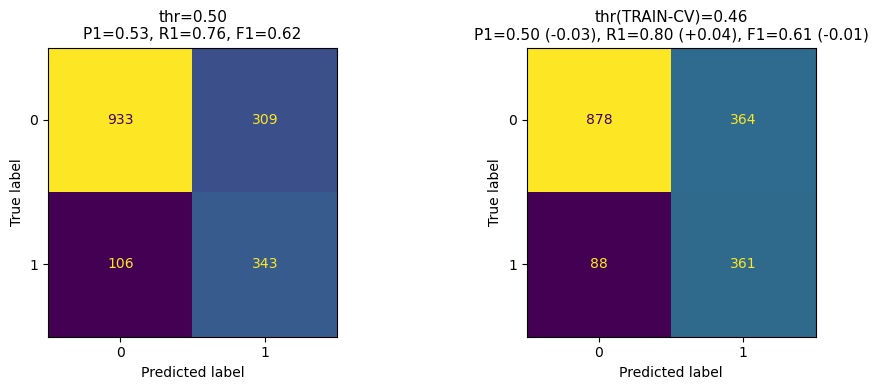

In [17]:
# Predicciones (asegurate de tener y_proba_rf_test y best_thr_rf_cv calculados)
y_pred_rf_05 = (y_proba_rf_test >= 0.5).astype(int)
y_pred_rf_cv = (y_proba_rf_test >= best_thr_rf_cv).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_rf_05)
cm_cv_rf = confusion_matrix(y_test, y_pred_rf_cv)

# Métricas para clase positiva (churn=1)
p05 = precision_score(y_test, y_pred_rf_05, pos_label=1)
r05 = recall_score(y_test, y_pred_rf_05, pos_label=1)
f05 = f1_score(y_test, y_pred_rf_05, pos_label=1)

pcv = precision_score(y_test, y_pred_rf_cv, pos_label=1)
rcv = recall_score(y_test, y_pred_rf_cv, pos_label=1)
fcv = f1_score(y_test, y_pred_rf_cv, pos_label=1)

# Deltas vs thr=0.5
dp, dr, df = pcv - p05, rcv - r05, fcv - f05

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(top=0.85)

ConfusionMatrixDisplay(cm_05).plot(ax=axes[0], colorbar=False)
axes[0].set_title(
    f"thr=0.50\n"
    f"P1={p05:.2f}, R1={r05:.2f}, F1={f05:.2f}",
    fontsize=11
)

ConfusionMatrixDisplay(cm_cv_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title(
    f"thr(TRAIN-CV)={best_thr_rf_cv:.2f}\n"
    f"P1={pcv:.2f} ({dp:+.2f}), R1={rcv:.2f} ({dr:+.2f}), F1={fcv:.2f} ({df:+.2f})",
    fontsize=11
)

plt.tight_layout()
plt.show()

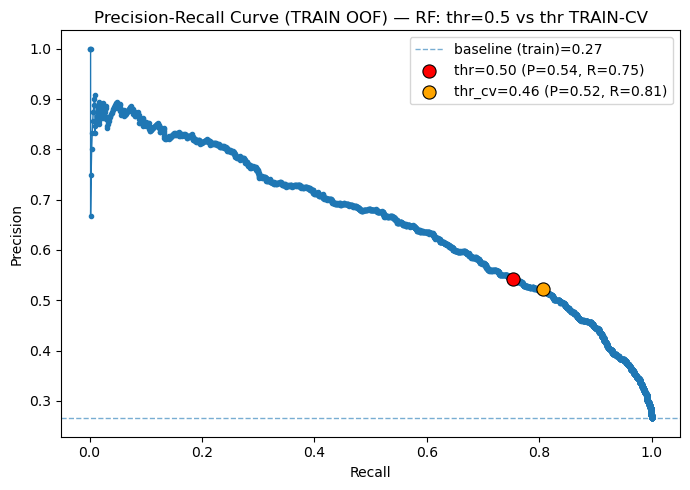

In [18]:
# Probabilidades OOF en TRAIN
y_proba_rf_oof = cross_val_predict(
    rf_best, x_train, y_train,
    cv=cv_thr, method="predict_proba", n_jobs=-1
)[:, 1]

# PR curve (TRAIN OOF)
prec, rec, thr = precision_recall_curve(y_train, y_proba_rf_oof)

# índices de thresholds a marcar (thr tiene len = len(prec)-1)
idx_05 = np.argmin(np.abs(thr - 0.5))
idx_cv = np.argmin(np.abs(thr - best_thr_rf_cv))

baseline = y_train.mean()

plt.figure(figsize=(7, 5))

# Curva (atrás)
plt.plot(rec, prec, marker=".", linewidth=1, zorder=1)

# Baseline
plt.axhline(baseline, linestyle="--", linewidth=1, alpha=0.6, zorder=0,
            label=f"baseline (train)={baseline:.2f}")

# Punto thr=0.5
plt.scatter(rec[:-1][idx_05], prec[:-1][idx_05], s=90, color="red",
            edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr=0.50 (P={prec[:-1][idx_05]:.2f}, R={rec[:-1][idx_05]:.2f})")

# Punto thr TRAIN-CV
plt.scatter(rec[:-1][idx_cv], prec[:-1][idx_cv], s=90, color="orange",
            edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr_cv={best_thr_rf_cv:.2f} (P={prec[:-1][idx_cv]:.2f}, R={rec[:-1][idx_cv]:.2f})")

plt.title("Precision-Recall Curve (TRAIN OOF) — RF: thr=0.5 vs thr TRAIN-CV")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

prep cols: 30 | importances: 30


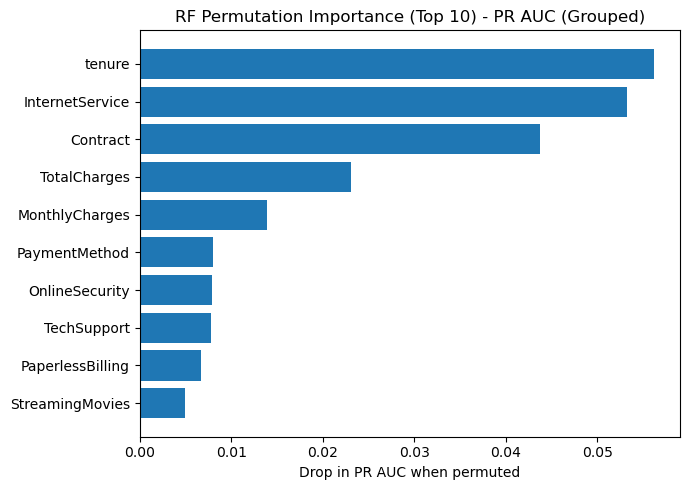

,original_var,importance
18,tenure,0.056243
3,InternetService,0.053225
0,Contract,0.043702
16,TotalCharges,0.023099
4,MonthlyCharges,0.013881
10,PaymentMethod,0.008013
7,OnlineSecurity,0.007849
15,TechSupport,0.007783
8,PaperlessBilling,0.006730
13,StreamingMovies,0.004977


In [19]:

prep = rf_best.named_steps["prep"]
rf   = rf_best.named_steps["rf"]

X_test_prep = prep.transform(x_test)          
feature_names = X_test_prep.columns.to_list()

perm = permutation_importance(
    rf, X_test_prep, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",   
    n_jobs=-1
)

print("prep cols:", len(feature_names), "| importances:", len(perm.importances_mean))

perm_imp = (pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
              .sort_values("importance", ascending=False))

# (opcional) agrupar por variable original
perm_imp["original_var"] = perm_imp["feature"].astype(str).str.split("_").str[0]
perm_grouped = (perm_imp.groupby("original_var", as_index=False)["importance"]
                        .sum()
                        .sort_values("importance", ascending=False))

top_n = 10
plot_df = perm_grouped.head(top_n).sort_values("importance")

plt.figure(figsize=(7, 5))
plt.barh(plot_df["original_var"], plot_df["importance"])
plt.xlabel("Drop in PR AUC when permuted")
plt.title(f"RF Permutation Importance (Top {top_n}) - PR AUC (Grouped)")
plt.tight_layout()
plt.show()

perm_grouped.head(15)

In [20]:
summary_rf = summary_metrics(
    y_test,
    y_proba_rf_test,
    model_name="RF",
    thr_f1=best_thr_rf_cv   # <- elegido en TRAIN-CV
)
summary_rf

,model,roc_auc,pr_auc,thr_05,P1_05,R1_05,F1_05,FN_05,FP_05,thr_f1,P1_f1,R1_f1,F1_f1,FN_f1,FP_f1
0,RF,0.834358,0.619736,0.5,0.526074,0.76392,0.62307,106,309,0.459992,0.497931,0.804009,0.614991,88,364


In [21]:
### Seguimos con el tercer modelo xgboosting

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        tree_method="hist",   
        n_jobs=-1
    ))
])

# Grid de parametros
param_grid_xgb = {
    "xgb__n_estimators": [300, 600],
    "xgb__learning_rate": [0.05, 0.10],
    "xgb__max_depth": [3, 5],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 5],
    "xgb__reg_lambda": [1, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV( 
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_xgb.fit(x_train, y_train)

print("XGB Best ROC AUC (CV):", grid_xgb.best_score_)
print("XGB Best params:", grid_xgb.best_params_)

xgb_best = grid_xgb.best_estimator_

Fitting 5 folds for each of 128 candidates, totalling 640 fits
XGB Best ROC AUC (CV): 0.8446835705432416
XGB Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 300, 'xgb__reg_lambda': 5, 'xgb__subsample': 1.0}


In [22]:
###comparacion de modelo con distintos tresholds y las distintas metricas
# Baseline thr=0.5 
y_proba_xgb_test = xgb_best.predict_proba(x_test)[:, 1]
thr_05 = 0.5
y_pred_xgb_05 = (y_proba_xgb_test >= thr_05).astype(int)

print("XGB ROC AUC (test):", roc_auc_score(y_test, y_proba_xgb_test))
print("XGB PR  AUC (test):", average_precision_score(y_test, y_proba_xgb_test))

print("\nMatriz de confusión (thr=0.5):\n", confusion_matrix(y_test, y_pred_xgb_05))
print("\nReporte (thr=0.5):\n", classification_report(y_test, y_pred_xgb_05))

# Threshold F1 elegido en TRAIN OOF (sin leakage)
cv_thr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_thr_xgb_cv = threshold_f1_cv(xgb_best, x_train, y_train, cv_thr)

print("\nXGB Best threshold (F1) elegido con TRAIN-CV:", best_thr_xgb_cv)

#Evaluación en TEST usando ese threshold
y_pred_xgb_cv = (y_proba_xgb_test >= best_thr_xgb_cv).astype(int)

print("\nMatriz confusión (thr TRAIN-CV):\n", confusion_matrix(y_test, y_pred_xgb_cv))
print("\nReporte (thr TRAIN-CV):\n", classification_report(y_test, y_pred_xgb_cv))

XGB ROC AUC (test): 0.8323022354202756
XGB PR  AUC (test): 0.6199666679705024

Matriz de confusión (thr=0.5):
 [[1105  137]
 [ 220  229]]

Reporte (thr=0.5):
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1242
           1       0.63      0.51      0.56       449

    accuracy                           0.79      1691
   macro avg       0.73      0.70      0.71      1691
weighted avg       0.78      0.79      0.78      1691


XGB Best threshold (F1) elegido con TRAIN-CV: 0.3172087073326111

Matriz confusión (thr TRAIN-CV):
 [[946 296]
 [116 333]]

Reporte (thr TRAIN-CV):
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1242
           1       0.53      0.74      0.62       449

    accuracy                           0.76      1691
   macro avg       0.71      0.75      0.72      1691
weighted avg       0.79      0.76      0.77      1691



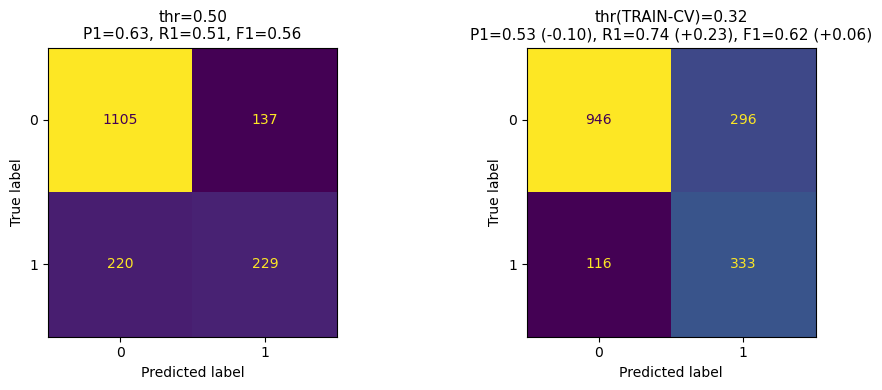

In [23]:
# Confusion matrices (XGB): thr=0.5 vs thr TRAIN-CV

# Predicciones con thresholds
y_pred_xgb_05 = (y_proba_xgb_test >= 0.5).astype(int)
y_pred_xgb_cv = (y_proba_xgb_test >= best_thr_xgb_cv).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_xgb_05)
cm_cv_xgb = confusion_matrix(y_test, y_pred_xgb_cv)

# Métricas clase positiva (churn=1)
p05 = precision_score(y_test, y_pred_xgb_05, pos_label=1)
r05 = recall_score(y_test, y_pred_xgb_05, pos_label=1)
f05 = f1_score(y_test, y_pred_xgb_05, pos_label=1)

pcv = precision_score(y_test, y_pred_xgb_cv, pos_label=1)
rcv = recall_score(y_test, y_pred_xgb_cv, pos_label=1)
fcv = f1_score(y_test, y_pred_xgb_cv, pos_label=1)

# Deltas vs thr=0.5
dp, dr, df = pcv - p05, rcv - r05, fcv - f05

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(top=0.85)

ConfusionMatrixDisplay(cm_05).plot(ax=axes[0], colorbar=False)
axes[0].set_title(
    f"thr=0.50\n"
    f"P1={p05:.2f}, R1={r05:.2f}, F1={f05:.2f}",
    fontsize=11
)

ConfusionMatrixDisplay(cm_cv_xgb).plot(ax=axes[1], colorbar=False)
axes[1].set_title(
    f"thr(TRAIN-CV)={best_thr_xgb_cv:.2f}\n"
    f"P1={pcv:.2f} ({dp:+.2f}), R1={rcv:.2f} ({dr:+.2f}), F1={fcv:.2f} ({df:+.2f})",
    fontsize=11
)

plt.tight_layout()
plt.show()

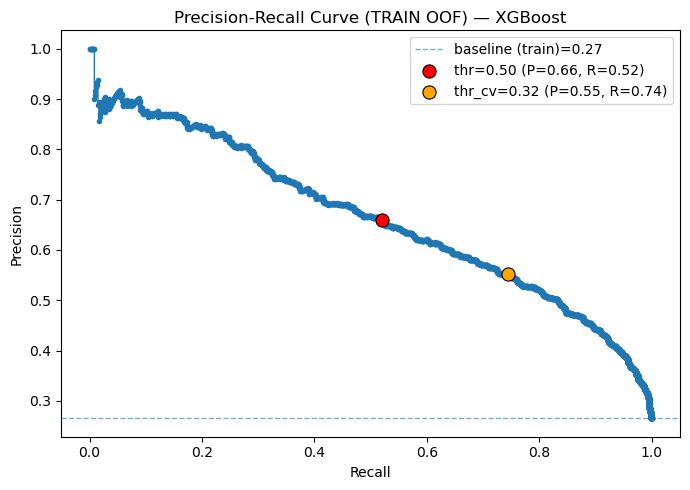

In [24]:
# PR curve consistente (XGB): TRAIN OOF + puntos thr=0.5 y thr TRAIN-CV
# =========================

y_proba_xgb_oof = cross_val_predict(
    xgb_best, x_train, y_train,
    cv=cv_thr, method="predict_proba", n_jobs=-1
)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, y_proba_xgb_oof)

# índices para ubicar los thresholds
idx_05 = np.argmin(np.abs(thr - 0.5))
idx_cv = np.argmin(np.abs(thr - best_thr_xgb_cv))

baseline = y_train.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, marker=".", linewidth=1, zorder=1)

plt.axhline(baseline, linestyle="--", linewidth=1, alpha=0.6, zorder=0,
            label=f"baseline (train)={baseline:.2f}")

plt.scatter(rec[:-1][idx_05], prec[:-1][idx_05], s=90, color="red",
            edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr=0.50 (P={prec[:-1][idx_05]:.2f}, R={rec[:-1][idx_05]:.2f})")

plt.scatter(rec[:-1][idx_cv], prec[:-1][idx_cv], s=90, color="orange",
            edgecolor="black", linewidth=0.8, zorder=5,
            label=f"thr_cv={best_thr_xgb_cv:.2f} (P={prec[:-1][idx_cv]:.2f}, R={rec[:-1][idx_cv]:.2f})")

plt.title("Precision-Recall Curve (TRAIN OOF) — XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

prep cols: 30 | importances: 30


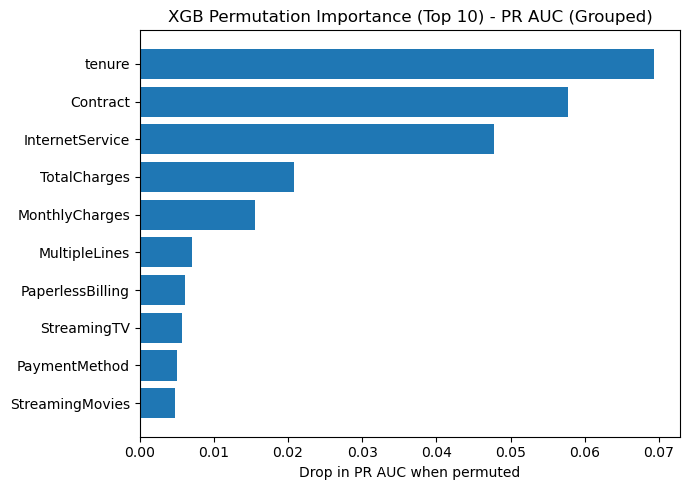

,original_var,importance
18,tenure,0.069392
0,Contract,0.057772
3,InternetService,0.047796
16,TotalCharges,0.020857
4,MonthlyCharges,0.015555
5,MultipleLines,0.007018
8,PaperlessBilling,0.006122
14,StreamingTV,0.005662
10,PaymentMethod,0.004988
13,StreamingMovies,0.004713


In [25]:
prep = xgb_best.named_steps["prep"]
xgb_clf = xgb_best.named_steps["xgb"]

X_test_prep = prep.transform(x_test)  # DataFrame
feature_names = X_test_prep.columns.to_list()

perm = permutation_importance(
    xgb_clf, X_test_prep, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

print("prep cols:", len(feature_names), "| importances:", len(perm.importances_mean))

perm_imp = (pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
              .sort_values("importance", ascending=False))

perm_imp["original_var"] = perm_imp["feature"].astype(str).str.split("_").str[0]
perm_grouped = (perm_imp.groupby("original_var", as_index=False)["importance"]
                        .sum()
                        .sort_values("importance", ascending=False))

top_n = 10
plot_df = perm_grouped.head(top_n).sort_values("importance")

plt.figure(figsize=(7, 5))
plt.barh(plot_df["original_var"], plot_df["importance"])
plt.title(f"XGB Permutation Importance (Top {top_n}) - PR AUC (Grouped)")
plt.xlabel("Drop in PR AUC when permuted")
plt.tight_layout()
plt.show()

perm_grouped.head(15)

In [26]:
### Resumen del modelo 

summary_xgb = summary_metrics(
    y_test,
    y_proba_xgb_test,
    model_name="XGB",
    thr_f1=best_thr_xgb_cv
)
summary_xgb

,model,roc_auc,pr_auc,thr_05,P1_05,R1_05,F1_05,FN_05,FP_05,thr_f1,P1_f1,R1_f1,F1_f1,FN_f1,FP_f1
0,XGB,0.832302,0.619967,0.5,0.625683,0.510022,0.561963,220,137,0.317209,0.529412,0.741648,0.617811,116,296


In [27]:
summary_all = pd.concat([summary_logit, summary_rf, summary_xgb], ignore_index=True)
summary_all

,model,roc_auc,pr_auc,thr_05,P1_05,R1_05,F1_05,FN_05,FP_05,thr_f1,P1_f1,R1_f1,F1_f1,FN_f1,FP_f1
0,Logit,0.829934,0.618721,0.5,0.621762,0.534521,0.574850,209,146,0.320710,0.525316,0.739421,0.614246,117,300
1,RF,0.834358,0.619736,0.5,0.526074,0.763920,0.623070,106,309,0.459992,0.497931,0.804009,0.614991,88,364
2,XGB,0.832302,0.619967,0.5,0.625683,0.510022,0.561963,220,137,0.317209,0.529412,0.741648,0.617811,116,296


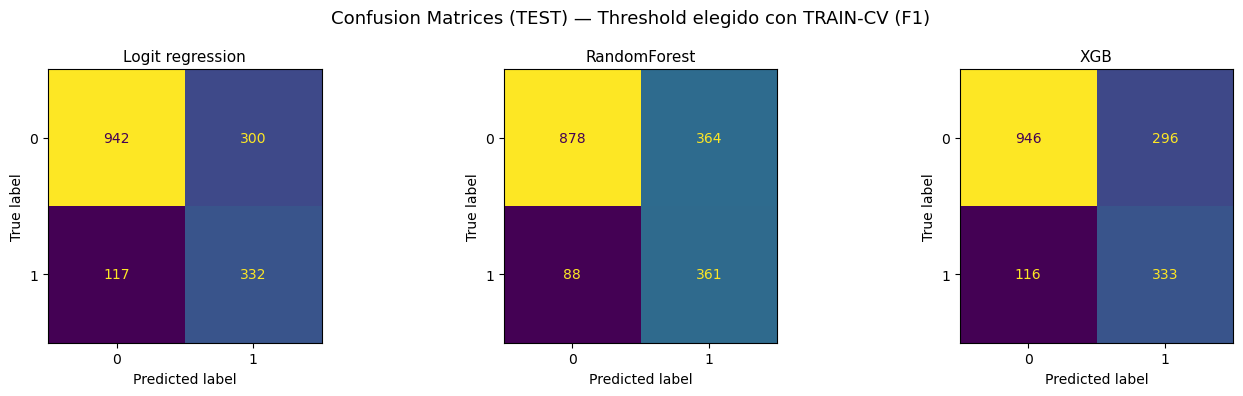

In [28]:
# Plot 1x3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plt.subplots_adjust(top=0.82)

ConfusionMatrixDisplay(cm_cv_logit).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logit regression", fontsize=11)

ConfusionMatrixDisplay(cm_cv_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("RandomForest", fontsize=11)

ConfusionMatrixDisplay(cm_cv_xgb).plot(ax=axes[2], colorbar=False)
axes[2].set_title("XGB", fontsize=11)

plt.suptitle("Confusion Matrices (TEST) — Threshold elegido con TRAIN-CV (F1)", fontsize=13)
plt.tight_layout()
plt.show()

Elegimos Random Forest porque minimiza los falsos negativos (FN) —es decir, reduce la cantidad de clientes que efectivamente churnean y el modelo no detecta—, manteniendo un nivel de falsos positivos (FP) moderado. Dado que en churn suele ser más costoso “perder” un churn real que contactar a un cliente que finalmente no churnea, priorizamos recall/FN en la decisión final.

In [29]:
final_model = rf_best
final_thr   = best_thr_rf_cv

y_proba_final = final_model.predict_proba(x_test)[:, 1]
y_pred_final  = (y_proba_final >= final_thr).astype(int)

print("Modelo final: RandomForest")
print("Threshold (TRAIN-CV):", final_thr)
print("ROC AUC (test):", roc_auc_score(y_test, y_proba_final))
print("PR  AUC (test):", average_precision_score(y_test, y_proba_final))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_final))
print("\nReporte:\n", classification_report(y_test, y_pred_final))

Modelo final: RandomForest
Threshold (TRAIN-CV): 0.45999196844984197
ROC AUC (test): 0.8343581549982246
PR  AUC (test): 0.6197360162009328

Matriz de confusión:
 [[878 364]
 [ 88 361]]

Reporte:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1242
           1       0.50      0.80      0.61       449

    accuracy                           0.73      1691
   macro avg       0.70      0.76      0.71      1691
weighted avg       0.80      0.73      0.75      1691



In [30]:
# === Entrenamiento final con todo el dataset etiquetado (x, y) ===
rf_final = grid_rf.best_estimator_   # ya incluye preprocessor + rf

rf_final.fit(x, y)  # reentrenar con todos los datos etiquetados

# Threshold final (opcional): el que ya elegiste con TRAIN-CV (best_thr_rf_cv)
# Si querés ser más fino: recalcularlo con CV sobre (x, y) también.

proba_data = rf_final.predict_proba(data_test)[:, 1]
pred_data  = (proba_data >= best_thr_rf_cv).astype(int)

In [31]:
# creamos un identificador para cada cliente
pred_out = data_test.copy()
pred_out = pred_out.reset_index(drop=True)
pred_out.insert(0, "row_id", pred_out.index)

# agregamos los scores
pred_out["proba_churn"] = proba_data
pred_out["pred_churn"]  = pred_data

# ranking (más riesgo arriba)
pred_rank = pred_out.sort_values("proba_churn", ascending=False)

# guardar un archivo liviano con lo esencial
pred_rank[["row_id", "proba_churn", "pred_churn"]].to_csv(
    "rf_churn_predictions.csv", index=False
)

pred_rank[["row_id", "proba_churn", "pred_churn"]].head(15)

,row_id,proba_churn,pred_churn
755,755,0.926485,1
211,211,0.921975,1
1028,1028,0.916519,1
1292,1292,0.916519,1
1378,1378,0.915993,1
228,228,0.913640,1
854,854,0.912992,1
802,802,0.912072,1
833,833,0.912056,1
50,50,0.911789,1


In [32]:
## Mostramos aquellos clientes con un riesgo mayor al 0.7 de churn.
(pred_rank["proba_churn"] >= 0.7).sum()

np.int64(290)

Se generó rf_churn_predictions.csv con un row_id por observación, la probabilidad estimada de churn (proba_churn) y la clase predicha (pred_churn) usando el threshold elegido con CV en train. El archivo está ordenado por riesgo para priorizar acciones de retención.